# Rabi Oscillation Experiment Prototype
#### Testing fast frequency sweeps by looping in Q1ASM

Both RF outputs go into a frequency mixer, the output of which goes into the oscilloscope

Author: Kyle MacRobbie

### Setup

In [1]:
# Imports
import waveform_helper as wh
import json
import matplotlib.pyplot as plt
import pyvisa
import numpy as np
import scipy
from numpy import random
from __future__ import annotations
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument
from qblox_instruments import Cluster, ClusterType
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module

In [2]:
# Run to get cluster IP
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.9.1 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
# Connect to cluster
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'

# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]

cluster.led_brightness('medium')

# reset cluster and print cluster status
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, Flags: NONE, Slot flags: NONE


In [4]:
modules
rf_module = modules[6]

In [5]:
print("\nQCM: {}\nQRM: {}\nRF: {}".format(rf_module.is_qcm_type, rf_module.is_qrm_type, rf_module.is_rf_type))


QCM: True
QRM: False
RF: True


### Setting up some shortcuts to help make using the oscilloscope easier

In [6]:
rm = pyvisa.ResourceManager()
rm.list_resources()


('ASRL3::INSTR', 'GPIB0::8::INSTR')

In [7]:
scope = rm.open_resource('GPIB0::8::INSTR')
print(scope.query('*IDN?'))

*IDN LECROY,WP715ZI,LCRY0716N47852,8.5.0



### Making waveforms and defining our sweep parameters

In [55]:
min_freq = 150e6
max_freq = 400e6
stationary_freq = 100e6
n_steps= 25
step_length = int(500 / n_steps)   # ns
freq_spacing = ((max_freq - min_freq) / n_steps)*4   # Need to multiply by 4 before putting into Q1ASM
print(freq_spacing)

40000000.0


In [56]:
# Waveforms
waveform_length = 200  # nanoseconds
waveforms = {
	"block": {
		"data": [1.0 for i in range(0, waveform_length)],
		"index": 0,
		}
}

### Making the sequences for our two outputs

In [57]:
# Setting up registers
seq_out_0 = f"""
		move		{int(n_steps)},R0	# Loop index
		move		{int(min_freq*4)},R1	# NCO frequency
"""

# Reset the phase of the NCO and begin the playing by setting the marker on for both outputs and markers
seq_out_0 += f"""
		reset_ph				# Reset the NCO phase to 0 degrees
		wait_sync	4			# Sync with the other sequencer
		set_mrk		{0b1111}	# Turn on all outputs and markers
"""

# Loop through the frequencies
seq_out_0 += f"""		
	loop:	play		0,0,{step_length} 			# Play the pulse
			add         R1,{int(freq_spacing)},R1	# Increment the NCO frequency
			nop
			set_freq	R1							# Update the NCO frequency
			loop		R0,@loop					# Loop
			nop
"""

# Set the markers to 0, disable the outputs, and stop the sequence
seq_out_0 += f"""
			set_mrk		{0b0000}	# Turn outputs and markers off
			upd_param	4			# Update the marker values
			stop					# Stop the sequence
	"""

In [58]:
# Setting up registers
seq_out_1 = f"""
		move		{int(n_steps)},R0	# Loop index
		nop
		move		{int(stationary_freq*4)},R1	# Constant NCO on output 1
		nop
"""

# Reset the phase of the NCO and begin the playing by setting the marker on for both outputs and markers
seq_out_1 += f"""
		reset_ph		# Reset the NCO phase to 0 degrees
		wait_sync	4	# Sync with the other sequencer
		nop
		nop
"""

# Loop through the frequencies
seq_out_1 += f"""		
	loop:	play		0,0,{step_length} 					# Play the pulse
			wait		12
			nop
			set_freq	R1							# NCO frequency
			loop		R0,@loop					# Loop
			nop
"""

# Set the markers to 0, disable the outputs, and stop the sequence
seq_out_1 += f"""
			nop
			nop
			stop	# Stop the sequence
	"""

### Upload sequences

In [59]:
sequence_0 = {
	"waveforms": waveforms,
    "weights": {},
    "acquisitions": {},
    "program": seq_out_0,
}
sequence_1 = {
	"waveforms": waveforms,
    "weights": {},
    "acquisitions": {},
    "program": seq_out_1,
}
rf_module.sequencer0.sequence(sequence_0)
rf_module.sequencer1.sequence(sequence_1)

### Function that plays sequence

In [50]:
def play_sequence():
	rf_module.disconnect_outputs() 		    # Disconnect outputs
	rf_module.sequencer0.connect_out0(True) # Connect to the first output
	rf_module.sequencer1.connect_out1(True) # Connect to the first output

	rf_module.sequencer0.mod_en_awg(True)   # Enable NCO modulation
	rf_module.out0_lo_en(True) 				# Enable LO modulation
	rf_module.sequencer0.nco_freq(200e6) 	# Set NCO frequency
	rf_module.out0_lo_freq(3e9) 			# Set LO frequency

	rf_module.sequencer1.mod_en_awg(True)   # Enable NCO modulation
	rf_module.out1_lo_en(True) 				# Enable LO modulation
	rf_module.sequencer1.nco_freq(100e6) 	# Set NCO frequency
	rf_module.out1_lo_freq(3e9) 			# Set LO frequency

	rf_module.sequencer0.sync_en(True)		# Enable sync
	rf_module.sequencer1.sync_en(True)		# Enable sync
	rf_module.arm_sequencer(0) 				# arm sequencer 2
	rf_module.arm_sequencer(1) 				# arm sequencer 2
	rf_module.start_sequencer() 			# start sequencers
	
	return None

### Oscilloscope shortcuts to set the scales, turn to single acquisition

In [60]:
scope.write(f'TIME_DIV {100e-9} S') # Setting time scale
scope.write(f'C3:VOLT_DIV {0.5} V') # Setting voltage scale on channel 3
scope.write(f'TRIG_DELAY -2e-8')	# Setting the time offset
scope.write(f'TRIG_MODE SINGLE')	# Turn to single acquisition mode

18

### Play the sequence

In [61]:
data_single = np.array(play_sequence())
print(rf_module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


### Stopping

In [91]:
rf_module.stop_sequencer(0)

# Print status of sequencer.
print(rf_module.get_sequencer_status(0))

# Reset the cluster
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


### Plotting after getting data from the ocsilloscope

In [76]:
data = np.genfromtxt("sweep.txt")
t = np.arange(0, len(data), 1) / 10   # ns

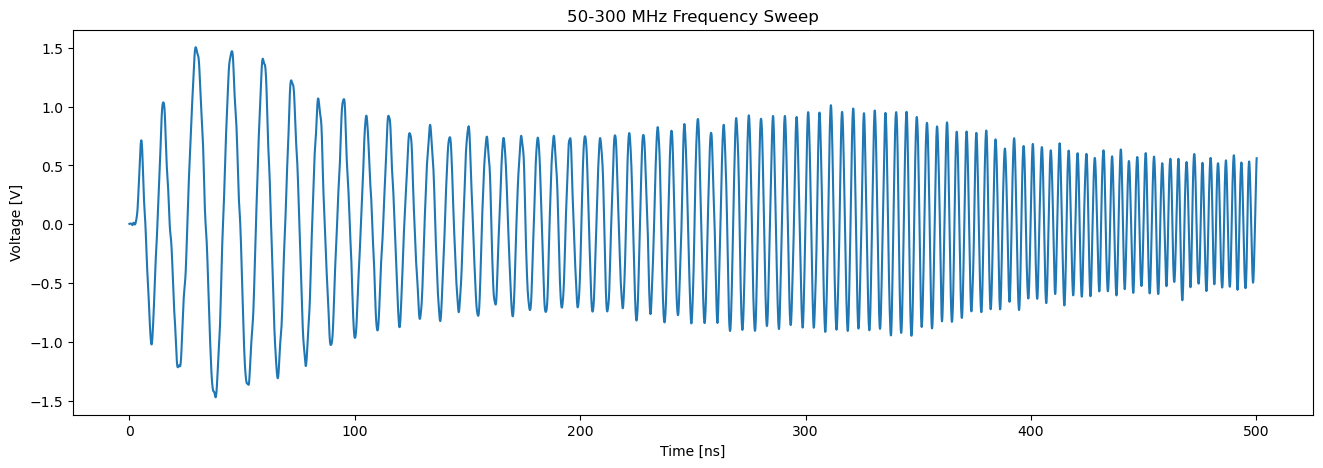

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))
ax.set_title("50-300 MHz Frequency Sweep")
ax.set_ylabel("Voltage [V]")
ax.set_xlabel("Time [ns]")
ax.plot(t, data)
plt.show()